In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor




In [5]:
df = pd.read_csv('/content/housing.csv')
print(df.shape)
df.head(10)

(489, 4)


,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0
5,6.430,5.21,18.7,602700.0
6,6.012,12.43,15.2,480900.0
7,6.172,19.15,15.2,569100.0
8,5.631,29.93,15.2,346500.0
9,6.004,17.10,15.2,396900.0


In [16]:
X = df.drop(columns='MEDV')
Y = df['MEDV']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [19]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)




In [22]:
from sklearn.metrics import r2_score, mean_squared_error
print("R2: ", r2_score(Y_test, y_pred))
print("MSE: ", mean_squared_error(Y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(Y_test, y_pred)))

R2:  0.8523419529990267
MSE:  3245169433.5
RMSE:  56966.38862961211


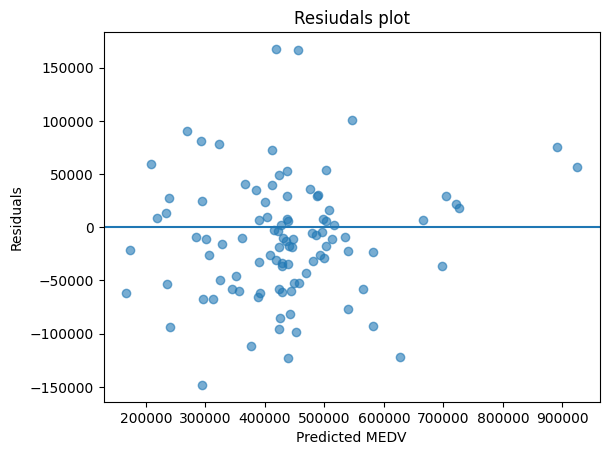

In [23]:
residuals = Y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0)
plt.xlabel("Predicted MEDV")
plt.ylabel('Residuals')
plt.title('Resiudals plot')
plt.show()